<a href="https://colab.research.google.com/github/Elkin535/A---HEURISTICA---Teoria-juego/blob/main/Manhattan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

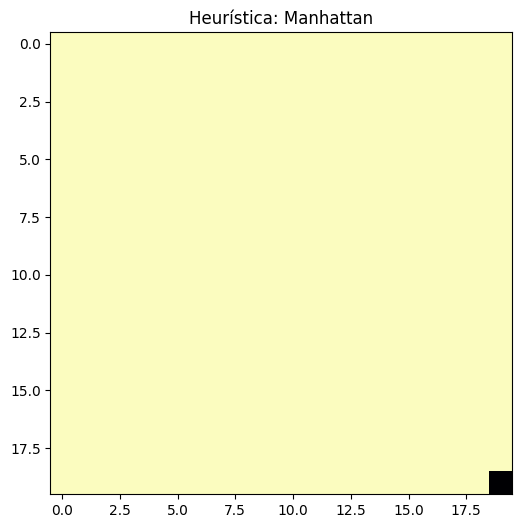

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython import display as ipythondisplay
import heapq
import time

def solve_with_heuristic(h_type="manhattan"):
    grid_size = 20
    start, goal = (0, 0), (19, 19)
    explored = np.zeros((grid_size, grid_size))

    def get_h(p1, p2):
        if h_type == "manhattan":
            return abs(p1[0]-p2[0]) + abs(p1[1]-p2[1])
        return np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

    pq = [(0, start)]
    visited = {start: 0}

    fig, ax = plt.subplots(figsize=(6,6))

    while pq:
        _, curr = heapq.heappop(pq)
        x, y = curr
        explored[x, y] = 1 # Marcar como explorado

        if curr == goal: break

        for dx, dy in [(0,1),(0,-1),(1,0),(-1,0)]:
            nx, ny = x+dx, y+dy
            if 0 <= nx < grid_size and 0 <= ny < grid_size:
                new_cost = visited[curr] + 1
                if (nx, ny) not in visited:
                    visited[(nx, ny)] = new_cost
                    priority = new_cost + get_h((nx, ny), goal)
                    heapq.heappush(pq, (priority, (nx, ny)))

        # Animación cada 5 pasos para que no sea eterno
        if len(visited) % 5 == 0:
            ax.clear()
            ax.imshow(explored, cmap='magma') # 'magma' da colores de fuego/calor
            ax.set_title(f"Heurística: {h_type.capitalize()}")
            ipythondisplay.clear_output(wait=True)
            ipythondisplay.display(fig)
            time.sleep(0.05)
    plt.close()

# Prueba cambiar a "euclidean" para ver la diferencia de forma
solve_with_heuristic("manhattan")